In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

from dpks import QuantMatrix
from dfmodel import DigitalFamilyBinary
from scanpy.experimental.pp import highly_variable_genes


In [2]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()

    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix

In [4]:
proteomics_data_train = pd.read_csv(
    "../0_data/proteins_test_filtered.tsv"
    , sep="\t"
)
clinical_data_train = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)
clinical_data_train['sample'] = clinical_data_train['injection']

In [16]:
import glob

prediction_files = glob.glob("predictions_test/*.tsv")

prediction_dfs = []

for file in prediction_files:

    predictions = pd.read_csv(
        file,
        sep='\t',
        index_col=0
    )

    prediction_dfs.append(predictions)


prediction_df = pd.concat(prediction_dfs, axis=1)


In [17]:
prediction_df

,renal_probability,cns_probability,liver_probability,coag_probability,cardiovasc_probability,resp_probability
SA_BOX_9-159_S1-D9_1_6172,0.007851,0.224753,0.078350,0.059393,0.005473,0.888355
SA_BOX_7-267_S4-H8_1_5971,0.998926,0.576252,0.822936,0.999707,0.918539,0.896902
SA_BOX_15-464_S4-G9_1_6763,0.021510,0.008478,0.057125,0.014997,0.274065,0.771084
SA_BOX_2-1700_S2-D11_1_6971,0.129400,0.267247,0.303462,0.474402,0.395635,0.992831
SA_BOX_7-1728_S4-F9_1_5977,0.414680,0.693056,0.079532,0.000905,0.029964,0.815805
...,...,...,...,...,...,...
SA_BOX_6-659_S2-F10_1_5887,0.971288,0.351271,0.001057,0.160596,0.616334,0.126964
SA_BOX_7-2061_S4-H5_1_5946,0.005207,0.275785,0.011343,0.000002,0.157826,0.076457
SA_BOX_2-764_S2-G2_1_6901,0.711154,0.179851,0.004338,0.783782,0.847802,0.651949
SA_BOX_6-774_S2-D10_1_5885,0.143688,0.114213,0.311127,0.833224,0.998123,0.047430


In [27]:
clinical_data_train = clinical_data_train.set_index("injection").join(
    prediction_df,
)

In [28]:
#X = X.loc[:, X.var() > X.var().median()]
protein_columns = prediction_df.columns.to_list()

In [29]:
from sklearn.preprocessing import StandardScaler

protein_scaler = StandardScaler()
clinical_data_train[protein_columns] = protein_scaler.fit_transform(clinical_data_train[protein_columns])

In [30]:
clinical_data_train['resp_dysfunction'] =  np.where(
    clinical_data_train['sofa_resp_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_resp_day3'] > 0, 1, 0
    )
)

clinical_data_train['renal_dysfunction'] = np.where(
    clinical_data_train['sofa_renal_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_renal_day2'] > 0, 1, 0
    )
)

clinical_data_train['cardiovasc_dysfunction'] = np.where(
    clinical_data_train['sofa_cardiovasc_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_cardiovasc_day3'] > 0, 1, 0
    )
)

clinical_data_train['coag_dysfunction'] = np.where(
    clinical_data_train['sofa_coag_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_coag_day3'] > 0, 1, 0
    )
)

clinical_data_train['cns_dysfunction'] = np.where(
    clinical_data_train['sofa_cns_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_cns_day3'] > 0, 1, 0
    )
)

clinical_data_train['liver_dysfunction'] = np.where(
    clinical_data_train['sofa_liver_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_liver_day3'] > 0, 1, 0
    )
)

In [31]:
df_estimator = DigitalFamilyBinary(n_neighbors=10, neighbor_metric="euclidean")

In [35]:
clinical_data_train = clinical_data_train.reset_index()

In [36]:
df_estimator.fit(clinical_data_train, features=protein_columns)

In [38]:
clinical_data_train['Resp Rate'] = df_estimator.predict(clinical_data_train, features=protein_columns, target_column="resp_dysfunction", bootstrap=False)

clinical_data_train['Renal Rate'] = df_estimator.predict(clinical_data_train, features=protein_columns, target_column="renal_dysfunction", bootstrap=False)

clinical_data_train['Cardio Rate'] = df_estimator.predict(clinical_data_train, features=protein_columns, target_column="cardiovasc_dysfunction", bootstrap=False)

clinical_data_train['Liver Rate'] = df_estimator.predict(clinical_data_train, features=protein_columns, target_column="liver_dysfunction", bootstrap=False)

clinical_data_train['CNS Rate'] = df_estimator.predict(clinical_data_train, features=protein_columns, target_column="cns_dysfunction", bootstrap=False)

clinical_data_train['Coag Rate'] = df_estimator.predict(clinical_data_train, features=protein_columns, target_column="coag_dysfunction", bootstrap=False)

In [39]:
display_columns = [
    "Resp Rate",
    "Renal Rate",
    "Cardio Rate",
    "Liver Rate",
    "CNS Rate",
    "Coag Rate",
]

In [43]:
display_columns = protein_columns

In [40]:
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_


positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

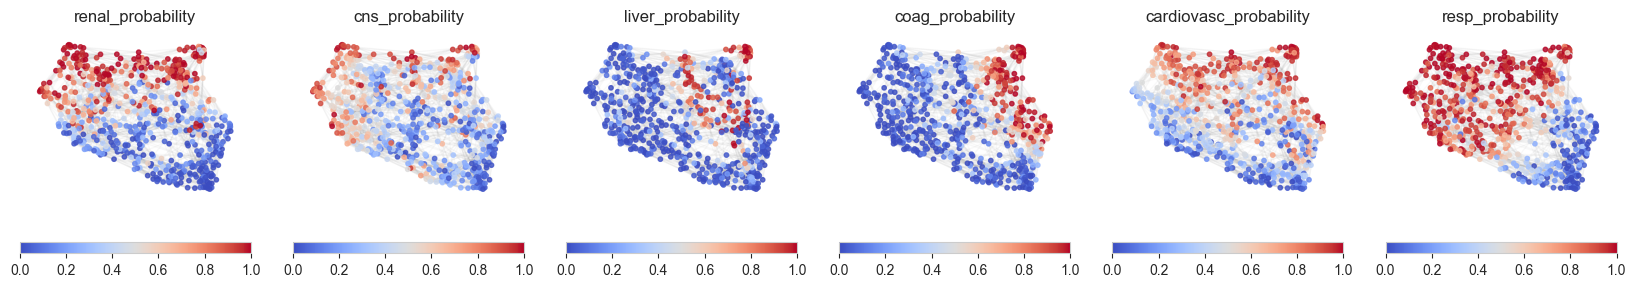

In [44]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

fig, axs = plt.subplots(
    nrows=1,
    ncols=6
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(clinical_data_train[[col]])

    color_map = dict(zip(clinical_data_train.index, values))
    node_colors = [color_map[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)

    sm = plt.cm.ScalarMappable(cmap="coolwarm")
    cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

    #cbar = fig.colorbar(ax=axs[i])

fig.set_size_inches((8.27 * 2, 3))
plt.tight_layout()

<Axes: >

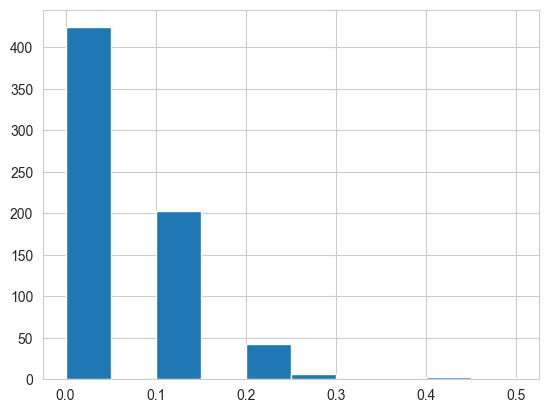

In [57]:
clinical_data_train['Resp Rate'].hist()

In [53]:
clinical_data_train[clinical_data_train['Liver Rate'] > clinical_data_train['Liver Rate'].mean()]

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,MOFA 6,MOFA 7,MOFA 8,MOFA 9,Resp Rate,Renal Rate,Cardio Rate,Liver Rate,CNS Rate,Coag Rate
0,0,SA_BOX_1-462_S1-C8_1_6848,-0.440508,-0.862829,0.347360,-0.182072,0.270374,1.0,0.694719,-0.555306,...,2.075218,5.136214e-13,6.124035e-13,1.420509e-11,0.0,0.1,0.1,0.1,0.0,0.0
5,5,SA_BOX_5-2486_S1-E5_1_5747,-2.145942,0.361468,0.390885,0.178498,0.000000,3.0,-0.670768,-0.792630,...,-0.343262,-2.618517e-14,-5.949421e-13,2.275279e-12,0.0,0.1,0.3,0.1,0.3,0.0
8,8,SA_BOX_12-743_S5-C8_1_6457,0.469057,-0.373111,1.130798,1.115981,1.726351,1.0,-0.378164,-0.296408,...,-1.802983,-1.026522e-12,2.379882e-12,-4.393604e-11,0.0,0.2,0.2,0.1,0.0,0.1
9,9,SA_BOX_11-710_S4-B7_1_6350,0.696449,0.116608,-0.087883,-0.362357,0.034848,1.0,0.109510,-0.253258,...,-0.796434,7.915237e-13,-2.108669e-12,3.509780e-11,0.0,0.4,0.2,0.4,0.0,0.4
10,10,SA_BOX_4-2039_S5-A6_1_5653,1.037535,0.116608,-0.087883,-1.227725,-1.378306,2.0,-1.646117,0.760760,...,-0.808831,7.555672e-13,-2.512984e-12,3.601156e-11,0.1,0.9,0.4,0.1,0.2,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,670,SA_BOX_7-719_S4-E10_1_5984,-0.213116,1.096046,-0.174932,1.620779,0.000000,1.0,-0.280629,-0.641606,...,0.885736,1.036060e-12,-1.733148e-12,4.381200e-11,0.0,0.3,0.1,0.1,0.3,0.2
671,671,SA_BOX_6-746_S2-E6_1_5853,0.923840,-1.352548,0.826128,0.250612,0.527311,1.0,1.279928,-0.544519,...,-0.874757,2.227112e-13,-8.406775e-13,9.857736e-12,0.1,0.1,0.2,0.2,0.1,0.1
673,673,SA_BOX_6-236_S2-E9_1_5878,-0.099421,-1.107689,-0.958370,0.899639,0.000000,1.0,-0.085559,-0.339558,...,-0.759815,3.038792e-12,-7.621672e-12,1.345356e-10,0.0,0.5,0.0,0.4,0.0,0.1
677,677,SA_BOX_8-2367_S5-C12_1_6096,-1.691159,1.096046,-0.523127,0.286670,0.420254,1.0,-1.353512,-0.576881,...,1.707447,6.145370e-13,-2.119101e-12,3.001513e-11,0.1,0.2,0.1,0.3,0.2,0.1


In [54]:
clinical_data_train[clinical_data_train['Liver Rate'] > 0]

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,MOFA 6,MOFA 7,MOFA 8,MOFA 9,Resp Rate,Renal Rate,Cardio Rate,Liver Rate,CNS Rate,Coag Rate
0,0,SA_BOX_1-462_S1-C8_1_6848,-0.440508,-0.862829,0.347360,-0.182072,0.270374,1.0,0.694719,-0.555306,...,2.075218,5.136214e-13,6.124035e-13,1.420509e-11,0.0,0.1,0.1,0.1,0.0,0.0
5,5,SA_BOX_5-2486_S1-E5_1_5747,-2.145942,0.361468,0.390885,0.178498,0.000000,3.0,-0.670768,-0.792630,...,-0.343262,-2.618517e-14,-5.949421e-13,2.275279e-12,0.0,0.1,0.3,0.1,0.3,0.0
8,8,SA_BOX_12-743_S5-C8_1_6457,0.469057,-0.373111,1.130798,1.115981,1.726351,1.0,-0.378164,-0.296408,...,-1.802983,-1.026522e-12,2.379882e-12,-4.393604e-11,0.0,0.2,0.2,0.1,0.0,0.1
9,9,SA_BOX_11-710_S4-B7_1_6350,0.696449,0.116608,-0.087883,-0.362357,0.034848,1.0,0.109510,-0.253258,...,-0.796434,7.915237e-13,-2.108669e-12,3.509780e-11,0.0,0.4,0.2,0.4,0.0,0.4
10,10,SA_BOX_4-2039_S5-A6_1_5653,1.037535,0.116608,-0.087883,-1.227725,-1.378306,2.0,-1.646117,0.760760,...,-0.808831,7.555672e-13,-2.512984e-12,3.601156e-11,0.1,0.9,0.4,0.1,0.2,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,670,SA_BOX_7-719_S4-E10_1_5984,-0.213116,1.096046,-0.174932,1.620779,0.000000,1.0,-0.280629,-0.641606,...,0.885736,1.036060e-12,-1.733148e-12,4.381200e-11,0.0,0.3,0.1,0.1,0.3,0.2
671,671,SA_BOX_6-746_S2-E6_1_5853,0.923840,-1.352548,0.826128,0.250612,0.527311,1.0,1.279928,-0.544519,...,-0.874757,2.227112e-13,-8.406775e-13,9.857736e-12,0.1,0.1,0.2,0.2,0.1,0.1
673,673,SA_BOX_6-236_S2-E9_1_5878,-0.099421,-1.107689,-0.958370,0.899639,0.000000,1.0,-0.085559,-0.339558,...,-0.759815,3.038792e-12,-7.621672e-12,1.345356e-10,0.0,0.5,0.0,0.4,0.0,0.1
677,677,SA_BOX_8-2367_S5-C12_1_6096,-1.691159,1.096046,-0.523127,0.286670,0.420254,1.0,-1.353512,-0.576881,...,1.707447,6.145370e-13,-2.119101e-12,3.001513e-11,0.1,0.2,0.1,0.3,0.2,0.1


In [55]:
clinical_data_train.to_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t",
    index=False
)